# Experiment 0A: ISI — Input Perturbation (Learnable Tau + Delay)

## Overview

Companion to `isi_tau.ipynb`: same input-perturbation protocol, but using
the SGD-delay variant (learnable tau **and** learnable per-neuron delays),
following `temporal_shd_project/code/synthetic/isi/isi_delay.py`.

A separate model is trained at each perturbation level f, and the resulting
accuracy curve can be compared with the SGD (`isi_tau.ipynb`) curve to
reproduce the SGD vs SGD-delay ordering reported in the paper.

| Property | Value |
|---|---|
| Architecture | Input (10) → delay → Hidden (100, learnable tau) → delay → Output (2) |
| Perturbation site | Input spike trains |
| Sweep | f ∈ {0, 0.2, 0.4, 0.6, 0.8, 1.0} |
| Max delay | 15 time steps |
| Dataset | ISI synthetic (`isi_dataset.h5`) |
| Framework | SLAYER (slayerPytorch) |

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import h5py

import slayerSNN as snn

MS = 1e-3  # Millisecond constant

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER and Training Parameters

In [2]:
# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 1000}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS = 100
EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 0.001
MAX_DELAY = 15  # Max delay in time steps (matches isi_delay.py)
SEED = 48

# --- Input-perturbation sweep ---
F_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

## 3. Load ISI Dataset

In [3]:
def load_isi_data(data_file: str = "isi_dataset.h5"):
    """Load ISI dataset from HDF5 file.

    Args:
        data_file: Path to the HDF5 file.

    Returns:
        Tuple of (X, Y, firing_rates, isis) arrays.
    """
    with h5py.File(data_file, "r") as f:
        X = f["X"][:]
        Y = f["Y"][:].ravel()
        firing_rates = f["firing_rates"][:] if "firing_rates" in f else None
        isis = f["isis"][:] if "isis" in f else None

    print(f"Loaded {data_file}: X={X.shape}, Y={Y.shape}")
    print(f"Classes: {np.unique(Y)}, Time steps: {X.shape[2]}")
    return X, Y, firing_rates, isis


X_all, Y_all, firing_rates_all, isis_all = load_isi_data("isi_dataset.h5")
NUM_NEURONS = X_all.shape[1]
NUM_CLASSES = len(np.unique(Y_all))
print(f"Network config: {NUM_NEURONS} input neurons, {NUM_CLASSES} classes")

Loaded isi_dataset.h5: X=(3598, 10, 10000), Y=(3598,)
Classes: [0 1], Time steps: 10000
Network config: 10 input neurons, 2 classes


## 4. Input-Layer Spike Perturbation

In [4]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        max_attempts: Max placement retries per spike.

    Returns:
        Perturbed spike train with the same shape.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] == 0:
                new_train[neuron_idx, new_t] = 1
                placed += 1

    return new_train

## 5. Dataset and Data Splitting

In [5]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(split_range: tuple, total: int) -> np.ndarray:
    """Return integer indices for the given fractional range."""
    return np.arange(int(split_range[0] * total), int(split_range[1] * total))


def build_perturbed_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    f: float,
    batch_size: int = 32,
    seed: int = 42,
) -> tuple:
    """Apply input perturbation at level *f*, then split into loaders."""
    np.random.seed(seed)
    X_proc = np.array([partial_randomize_spike_train(x, f) for x in X])

    train_idx = get_split_indices(TRAIN_RANGE, len(X_proc))
    val_idx = get_split_indices(VAL_RANGE, len(X_proc))
    test_idx = get_split_indices(TEST_RANGE, len(X_proc))

    train_ds = SpikeDataset(X_proc[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X_proc[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X_proc[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"  f={f:.1f} — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture (Tau + Delay)

Same architecture as the SGD model plus two SLAYER `delay` modules: one
applied to the input, one applied between the hidden and output layers.
Delay parameters are initialised uniformly in `[0, MAX_DELAY]`.

```
Input → delay1 → PSP filter → fc1 → spike → delay2 → PSP → fc2 → spike
```

In [6]:
class ISIDelayNetwork(nn.Module):
    """SLAYER SNN for ISI with learnable PSP filter and learnable delays."""

    def __init__(
        self,
        num_neurons: int,
        num_classes: int,
        hidden_units: int = 100,
        max_delay: int = 15,
    ):
        super().__init__()
        self.max_delay = max_delay

        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer

        self.fc1 = nn.utils.weight_norm(
            slayer.dense(num_neurons, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        # Learnable PSP filter (effective tau)
        self.psp_filter = slayer.pspFilter(nFilter=1, filterLength=50, filterScale=1)
        self._initialize_alpha_filter()

        # Learnable delay modules
        self.delay1 = slayer.delay(num_neurons)
        self.delay2 = slayer.delay(hidden_units)
        self._initialize_delays()

    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape."""
        tau = 50 * MS
        Ts = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]

        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))

        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def _initialize_delays(self) -> None:
        """Initialise delays uniformly in [0, max_delay]."""
        with torch.no_grad():
            if hasattr(self.delay1, "delay"):
                self.delay1.delay.data.uniform_(0, self.max_delay)
            if hasattr(self.delay2, "delay"):
                self.delay2.delay.data.uniform_(0, self.max_delay)

    def get_tau(self) -> torch.Tensor:
        """Estimate the effective tau from the learned filter."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        if len(weights) > 0:
            peak_idx = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    def get_delays(self) -> dict:
        """Return current delay-parameter arrays as numpy."""
        delays = {}
        if hasattr(self.delay1, "delay"):
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
        if hasattr(self.delay2, "delay"):
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Standard forward pass through delays, PSP filter, and FC layers."""
        x = self._prepare_input(x)
        x = self.delay1(x)
        x_filtered = self.psp_filter(x)
        hidden_spikes = self.slayer.spike(self.fc1(x_filtered))
        hidden_spikes = self.delay2(hidden_spikes)
        return self.slayer.spike(self.fc2(self.slayer.psp(hidden_spikes)))

## 7. Training Loop

Tau and delay parameters use higher learning rates (×10 and ×5 respectively),
matching the original `isi_delay.py` configuration.

In [7]:
def build_param_groups(net: ISIDelayNetwork, base_lr: float) -> list:
    """Group parameters into regular / tau / delay with separate LRs."""
    regular_params, tau_params, delay_params = [], [], []
    for name, param in net.named_parameters():
        if "delay" in name:
            delay_params.append(param)
        elif "psp_filter" in name or "logit_tau" in name:
            tau_params.append(param)
        else:
            regular_params.append(param)

    groups = [{"params": regular_params, "lr": base_lr}]
    if tau_params:
        groups.append({"params": tau_params, "lr": base_lr * 10})
    if delay_params:
        groups.append({"params": delay_params, "lr": base_lr * 5})
    return groups


def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_neurons: int,
    num_classes: int,
    hidden_units: int = 100,
    max_delay: int = 15,
    epochs: int = 301,
    lr: float = 0.001,
    seed: int = 42,
) -> tuple:
    """Train the ISIDelayNetwork; returns (net, log)."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    net = ISIDelayNetwork(num_neurons, num_classes, hidden_units, max_delay).to(device)

    loss_fn = snn.spikeLoss.spikeLoss({
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {"error": {"type": "ProbSpikes"}},
    }).to(device)

    optimizer = snn.utils.optim.Nadam(build_param_groups(net, lr))
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[300], gamma=0.5)

    best_val_loss = float("inf")
    best_model_state = None
    tau_history: list = []
    delay_history: list = []

    log = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "tau": [],
        "delay1_mean": [],
        "delay2_mean": [],
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc="Training") as pbar:
        for epoch in range(epochs):
            net.train()
            epoch_loss = 0.0
            batch_count = 0

            for x_batch, y_batch in train_loader:
                if x_batch.dim() == 3:
                    x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device).long()

                outputs = net(x_batch)
                loss = loss_fn.probSpikes(outputs, y_batch)
                epoch_loss += loss.item()
                batch_count += 1

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pbar.update(1)

            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    if x_batch.dim() == 3:
                        x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                    x_batch = x_batch.to(device).float()
                    y_batch = y_batch.to(device).long()
                    outputs = net(x_batch)
                    val_loss += loss_fn.probSpikes(outputs, y_batch).item()

            val_loss /= len(val_loader)
            epoch_loss /= batch_count
            tau_val = net.get_tau().item() / MS
            delays = net.get_delays()
            tau_history.append(tau_val)
            delay_history.append(delays)

            log["epoch"].append(epoch)
            log["train_loss"].append(epoch_loss)
            log["val_loss"].append(val_loss)
            log["tau"].append(tau_val)
            log["delay1_mean"].append(float(np.mean(delays["delay1"])) if "delay1" in delays else 0.0)
            log["delay2_mean"].append(float(np.mean(delays["delay2"])) if "delay2" in delays else 0.0)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.clone() for k, v in net.state_dict().items()}

            scheduler.step()
            avg_delay = np.mean(
                [np.mean(d) for d in delays.values() if len(d) > 0]
            ) if delays else 0.0
            pbar.set_postfix(
                epoch=epoch + 1,
                val_loss=f"{val_loss:.4f}",
                best=f"{best_val_loss:.4f}",
                tau=f"{tau_val:.1f}ms",
                delay=f"{avg_delay:.1f}",
            )

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    log["tau_history"] = tau_history
    return net, log

## 8. Test Function

In [8]:
def test_model(net: ISIDelayNetwork, test_loader: DataLoader) -> float:
    """Compute test accuracy on the (already perturbed) test loader."""
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            if x_batch.dim() == 3:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3)
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs = net(x_batch)
            predicted = snn.predict.getClass(outputs)
            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total

## 9. Run the Input-Perturbation Sweep

In [9]:
os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

sweep_results: dict = {}
training_logs: dict = {}

for f_val in F_VALUES:
    print(f"\n{'=' * 60}")
    print(f"Training with input perturbation f = {f_val} (tau + delay)")
    print(f"{'=' * 60}")

    train_loader, val_loader, test_loader = build_perturbed_dataloaders(
        X_all, Y_all, f=f_val, batch_size=BATCH_SIZE, seed=SEED
    )

    net, log = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        num_neurons=NUM_NEURONS,
        num_classes=NUM_CLASSES,
        hidden_units=HIDDEN_UNITS,
        max_delay=MAX_DELAY,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        seed=SEED,
    )

    test_acc = test_model(net, test_loader)
    print(f"\nf={f_val}: test accuracy = {test_acc:.4f}")

    sweep_results[f_val] = test_acc
    training_logs[f_val] = log

    model_path = f"data/isi_delay_input_f{int(f_val * 10):02d}.pt"
    torch.save(net.state_dict(), model_path)
    print(f"Model saved to {model_path}")


Training with input perturbation f = 0.0 (tau + delay)
  f=0.0 — Train: 2158, Val: 540, Test: 540


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Training:   0%|          | 0/680 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Training: 100%|██████████| 680/680 [01:30<00:00,  7.48it/s, best=0.1721, delay=7.5, epoch=10, tau=66.0ms, val_loss=0.1721]



f=0.0: test accuracy = 0.9648
Model saved to data/isi_delay_input_f00.pt

Training with input perturbation f = 0.2 (tau + delay)


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  f=0.2 — Train: 2158, Val: 540, Test: 540


...


f=0.6: test accuracy = 0.6574
Model saved to data/isi_delay_input_f06.pt

Training with input perturbation f = 0.8 (tau + delay)
  f=0.8 — Train: 2158, Val: 540, Test: 540


Training: 100%|██████████| 680/680 [01:26<00:00,  7.89it/s, best=0.6831, delay=6.7, epoch=10, tau=10.0ms, val_loss=0.6831]



f=0.8: test accuracy = 0.5574
Model saved to data/isi_delay_input_f08.pt

Training with input perturbation f = 1.0 (tau + delay)
  f=1.0 — Train: 2158, Val: 540, Test: 540


Training: 100%|██████████| 680/680 [01:26<00:00,  7.88it/s, best=0.6882, delay=6.7, epoch=10, tau=10.0ms, val_loss=0.6882]



f=1.0: test accuracy = 0.5222
Model saved to data/isi_delay_input_f10.pt


## 10. Plot Accuracy vs Input Perturbation

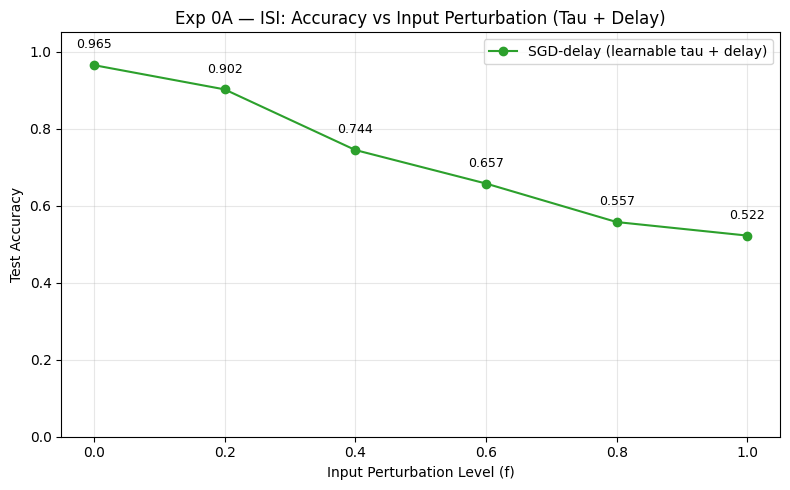

Figure saved to log/isi_delay_input_perturbation.png


In [10]:
def plot_input_perturbation_curve(results: dict) -> None:
    """Plot accuracy vs input perturbation level f."""
    f_vals = sorted(results.keys())
    accs = [results[f] for f in f_vals]

    plt.figure(figsize=(8, 5))
    plt.plot(f_vals, accs, "o-", color="tab:green",
             label="SGD-delay (learnable tau + delay)")
    plt.xlabel("Input Perturbation Level (f)")
    plt.ylabel("Test Accuracy")
    plt.title("Exp 0A — ISI: Accuracy vs Input Perturbation (Tau + Delay)")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, acc in zip(f_vals, accs):
        plt.annotate(
            f"{acc:.3f}",
            (f_val, acc),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.savefig("log/isi_delay_input_perturbation.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved to log/isi_delay_input_perturbation.png")


plot_input_perturbation_curve(sweep_results)

## 11. Save Results

In [11]:
results_serialisable = {str(f_val): float(acc) for f_val, acc in sweep_results.items()}
results_path = "log/isi_delay_input_perturbation_results.json"
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Results saved to {results_path}")

logs_serialisable = {
    str(f_val): {
        k: [float(v) for v in vals] if isinstance(vals, list) else vals
        for k, vals in log.items()
    }
    for f_val, log in training_logs.items()
}
logs_path = "log/isi_delay_input_perturbation_training_logs.json"
with open(logs_path, "w") as fp:
    json.dump(logs_serialisable, fp, indent=2)
print(f"Training logs saved to {logs_path}")

Results saved to log/isi_delay_input_perturbation_results.json
Training logs saved to log/isi_delay_input_perturbation_training_logs.json
